# Multi Layer Perceptron

## 1. Load, Split, and Balance

In [62]:
import pandas as pd
import numpy as np

# Load dataset
url = "https://www.dropbox.com/s/bf7i7qjftk7cmzq/acs2017_census_tract_data.csv?dl=1"
df = pd.read_csv(url)

# Remove rows with missing values
df_clean = df.dropna()

# Encode string columns as integers
df_clean['State'] = df_clean['State'].astype('category').cat.codes
df_clean['County'] = df_clean['County'].astype('category').cat.codes

# Drop 'County' due to high cardinality and potential overfitting
df_clean = df_clean.drop(columns=['County'])

# Display cleaned data info
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 72718 entries, 0 to 74000
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TractId           72718 non-null  int64  
 1   State             72718 non-null  int8   
 2   TotalPop          72718 non-null  int64  
 3   Men               72718 non-null  int64  
 4   Women             72718 non-null  int64  
 5   Hispanic          72718 non-null  float64
 6   White             72718 non-null  float64
 7   Black             72718 non-null  float64
 8   Native            72718 non-null  float64
 9   Asian             72718 non-null  float64
 10  Pacific           72718 non-null  float64
 11  VotingAgeCitizen  72718 non-null  int64  
 12  Income            72718 non-null  float64
 13  IncomeErr         72718 non-null  float64
 14  IncomePerCap      72718 non-null  float64
 15  IncomePerCapErr   72718 non-null  float64
 16  Poverty           72718 non-null  float64
 17

/var/folders/k6/vh9m1qvx7s37pn22yfvrbc3c0000gn/T/ipykernel_3441/431303455.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['State'] = df_clean['State'].astype('category').cat.codes
/var/folders/k6/vh9m1qvx7s37pn22yfvrbc3c0000gn/T/ipykernel_3441/431303455.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['County'] = df_clean['County'].astype('category').cat.codes


In [63]:
# Quantize 'ChildPoverty' into 4 balanced classes
df_clean['ChildPovertyClass'] = pd.qcut(df_clean['ChildPoverty'], q=4, labels=False)

# Verify class distribution
print(df_clean['ChildPovertyClass'].value_counts())

ChildPovertyClass
0    18229
1    18171
3    18170
2    18148
Name: count, dtype: int64


In [64]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['ChildPoverty', 'ChildPovertyClass'])
y = df_clean['ChildPovertyClass']

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set size: {len(X_train)}, Test set size: {len(X_test)}")

Training set size: 58174, Test set size: 14544


## 2. Pre-processing and Initial Modeling

In [65]:
import numpy as np
from scipy.special import expit
import sys
import pandas as pd
class TwoLayerPerceptronBase(object):
    def __init__(self, n_hidden=30,
                 C=0.0, epochs=500, eta=0.001, random_state=None):
        np.random.seed(random_state)
        
        self.n_hidden = n_hidden
        self.l2_C = C
        self.epochs = epochs
        self.eta = eta
        
    @staticmethod
    def _encode_labels(y):
        """Encode labels into one-hot representation"""
        onehot = pd.get_dummies(y).values.T
            
        return onehot

    def _initialize_weights(self):
        """Initialize weights with small random numbers."""
        W1_num_elems = (self.n_features_)*self.n_hidden
        W1 = np.random.uniform(-1.0, 1.0, size=W1_num_elems)
        W1 = W1.reshape(self.n_hidden, self.n_features_) # reshape to be W
        b1 = np.zeros((self.n_hidden, 1))
        
        W2_num_elems = (self.n_hidden)*self.n_output_
        W2 = np.random.uniform(-1.0, 1.0, size=W2_num_elems)
        W2 = W2.reshape(self.n_output_, self.n_hidden)
        b2 = np.zeros((self.n_output_, 1))
        
        return W1, W2, b1, b2
    
    @staticmethod
    def _sigmoid(z):
        """Use scipy.special.expit to avoid overflow"""
        # 1.0 / (1.0 + np.exp(-z))
        return expit(z)
    
    
    @staticmethod
    def _L2_reg(lambda_, W1, W2):
        """Compute L2-regularization cost"""
        # only compute for non-bias terms
        return (lambda_) * np.sqrt(np.mean(W1 ** 2) + np.mean(W2 ** 2))
    
    def _cost(self,A3,Y_enc,W1,W2):
        '''Get the objective function value'''
        cost = np.mean((Y_enc-A3)**2)
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        return cost + L2_term

In [66]:
class TwoLayerPerceptron(TwoLayerPerceptronBase):
    def _feedforward(self, X, W1, W2, b1, b2):
        """Compute feedforward step
        -----------
        X : Input layer with original features.
        W1: Weight matrix for input layer -> hidden layer.
        W2: Weight matrix for hidden layer -> output layer.
        ----------
        a1-a3 : activations into layer (or output layer)
        z1-z2 : layer inputs 

        """
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        return A1, Z1, A2, Z2, A3
    
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # need to vectorize this computation!
        # See additional code and derivation below!
        pass
    
    def predict(self, X):
        """Predict class labels"""
        _, _, _, _, A3 = self._feedforward(X, self.W1, self.W2, self.b1, self.b2)
        y_pred = np.argmax(A3, axis=0)
        return y_pred
    
    
    def fit(self, X, y, print_progress=False):
        """ Learn weights from training data."""
        
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.b1, self.b2 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):

            if print_progress>0 and (i+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (i+1, self.epochs))
                sys.stderr.flush()

            # feedforward all instances
            A1, Z1, A2, Z2, A3 = self._feedforward(X_data,self.W1,self.W2, self.b1, self.b2)
            
            cost = self._cost(A3,Y_enc,self.W1,self.W2)
            self.cost_.append(cost)

            # compute gradient via backpropagation
            gradW1, gradW2, gradb1, gradb2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2, Y_enc=Y_enc,
                                              W1=self.W1, W2=self.W2)

            self.W1 -= self.eta * gradW1
            self.W2 -= self.eta * gradW2
            self.b1 -= self.eta * gradb1
            self.b2 -= self.eta * gradb2
            

        return self

In [67]:
class TwoLayerPerceptronVectorized(TwoLayerPerceptron):
    # just need a different gradient calculation
    def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
        """ Compute gradient step using backpropagation.
        """
        # vectorized backpropagation
        V2 = -2*(Y_enc-A3)*A3*(1-A3)
        V1 = A2*(1-A2)*(W2.T @ V2)
        
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T
        
        gradb2 = np.sum(V2, axis=1).reshape((-1,1))
        gradb1 = np.sum(V1, axis=1).reshape((-1,1))
        
        
        # regularize weights that are not bias terms
        gradW1 += W1 * self.l2_C * 2
        gradW2 += W2 * self.l2_C * 2 

        return gradW1, gradW2, gradb1, gradb2

In [68]:
from scipy.optimize import fmin_bfgs
from scipy.optimize import fmin_l_bfgs_b
class TLPVectorizedBFGS(TwoLayerPerceptronVectorized):
    
    def __init__(self, gtol=1e-5, **kwds):        
        # need to add to the original initializer 
        self.gtol = gtol
        
        # but keep other keywords
        super().__init__(**kwds)
        
    @staticmethod
    def _pack(in1, in2, in3, in4):
        '''Pack and flatten input vectors '''
        return np.hstack((in1.flatten(),in2.flatten(),in3.flatten(),in4.flatten()))
    
    def _unpack(self, in_tot):
        '''Undo packing according to layer weight sizes'''
        start = 0
        end = self.W1.size
        out1 = in_tot[start:end].reshape(self.W1.shape)
        start = end
        end += self.W2.size
        out2 = in_tot[start:end].reshape(self.W2.shape)
        start = end
        end += self.b1.size
        out3 = in_tot[start:end].reshape(self.b1.shape)
        start = end
        end += self.b2.size
        out4 = in_tot[start:end].reshape(self.b2.shape)
        return out1, out2, out3, out4
    
    def _calc_cost_gradient_packed(self,W,X_data,Y_enc):
        '''Unpack and get cost, gradient for bfgs'''
        W1, W2, b1, b2 = self._unpack(W) 
        # feedforward all instances
        A1, Z1, A2, Z2, A3 = self._feedforward(X_data, W1, W2, b1, b2)
        
        cost = np.sum((Y_enc-A3)**2)
        L2_term = self._L2_reg(self.l2_C, W1, W2)
        cost = cost + L2_term
        #perform back prop to get gradients
        gradW1,gradW2,gradb1,gradb2 = self._get_gradient(A1=A1, A2=A2, A3=A3,Z1=Z1, Z2=Z2, Y_enc=Y_enc,
                                         W1=W1, W2=W2)
        return cost, self._pack(gradW1,gradW2,gradb1,gradb2)
    
    def _cost_packed(self,W,X_data,Y_enc):
        '''Unpack and calculate MSE for bfgs'''
        W1, W2, b1, b2 = self._unpack(W)
        _, _, _, _, A3 = self._feedforward(X_data,W1,W2,b1,b2)
        return np.sum((Y_enc-A3)**2)
    
    def fit(self,X,y,print_progress=0):
        '''Learn weights from training data'''
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.b1, self.b2 = self._initialize_weights()
        
        # make initial matrices into single row vector
        W = self._pack(self.W1,self.W2, self.b1, self.b2)
        
        if print_progress>0:
            def callback(xd):
                callback.counter += 1
                if callback.counter%print_progress==0:
                    sys.stderr.write('\rEpoch: %d/%d (max)' % (callback.counter,callback.epochs))
                    sys.stderr.flush()

            callback.counter = 0
            callback.epochs = self.epochs
            
        else:
            callback = None
            
        # compute gradient optimum with bfgs
        W_best,_,props = fmin_l_bfgs_b(
                        x0=W,
                        func=self._calc_cost_gradient_packed,
                        maxfun=self.epochs,
                        callback=callback,
                        pgtol=self.gtol,
                        args=(X_data, Y_enc))
        
        self.W1, self.W2, self.b1, self.b2 = self._unpack(W_best)
        if print_progress:
            print(props)

In [69]:
from scipy.optimize import fmin_bfgs
from scipy.optimize import fmin_l_bfgs_b
class TLPVectorizedMiniBatch(TwoLayerPerceptronVectorized):
    def __init__(self, alpha=0.1, decrease_const=0.0, shuffle=True, minibatches=1, **kwds):        
        # but keep other keywords
        super().__init__(**kwds)
        
        # need to add to the original initializer 
        self.alpha = alpha
        self.decrease_const = decrease_const
        self.shuffle = shuffle
        self.minibatches = minibatches
        
        
    def fit(self, X, y, print_progress=0):
        """ Learn weights from training data."""
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # init weights and setup matrices
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.b1, self.b2 = self._initialize_weights()
        
        # start momentum at zero for previous updates
        rho_W1_prev = np.zeros(self.W1.shape) # for momentum
        rho_W2_prev = np.zeros(self.W2.shape) # for momentum

        self.cost_ = []
        
        # outer loop: go through all data one time (epochs)
        for k in range(self.epochs):

            # adaptive learning rate
            eta = self.eta**(1+self.decrease_const*k)# decreasing learning rate
            eta = max(eta, self.eta/1000)
            # there are many forms of adaptive learning rates out there!

            if print_progress>0 and (k+1)%print_progress==0:
                sys.stderr.write('\rEpoch: %d/%d' % (k+1, self.epochs))
                sys.stderr.flush()

            if self.shuffle:
                # shuffle the data so batches ar different
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            # use numpy split to split into equal sized batches 
            # num batches == self.minibatches
            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            mini_cost = []
            # inner loop: go through all mini-batches of data
            for idx in mini: # iterate through each batch

                # feedforward
                A1, Z1, A2, Z2, A3 = self._feedforward(X_data[idx],
                                                       self.W1,
                                                       self.W2,
                                                       self.b1,
                                                       self.b2
                                                      )
                
                cost = self._cost(A3,Y_enc[:, idx],self.W1,self.W2)
                mini_cost.append(cost) # this appends cost of mini-batch only

                # compute gradient via backpropagation
                gradW1, gradW2, gradb1, gradb2 = self._get_gradient(A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2,
                                                  Y_enc=Y_enc[:, idx],
                                                  W1=self.W1, W2=self.W2)

                # now use simple momentum to update values
                rho_W1 = eta * gradW1 + (self.alpha * rho_W1_prev) 
                rho_W2 = eta * gradW2 + (self.alpha * rho_W2_prev)
                self.W1 -= rho_W1  # update with momentum
                self.W2 -= rho_W2  # update with momentum
                rho_W1_prev, rho_W2_prev = rho_W1, rho_W2
                
                self.b1 -= eta * gradb1 
                self.b2 -= eta * gradb2 

            self.cost_.append(mini_cost)
            
        return self

Model 1 Accuracy: 0.2507


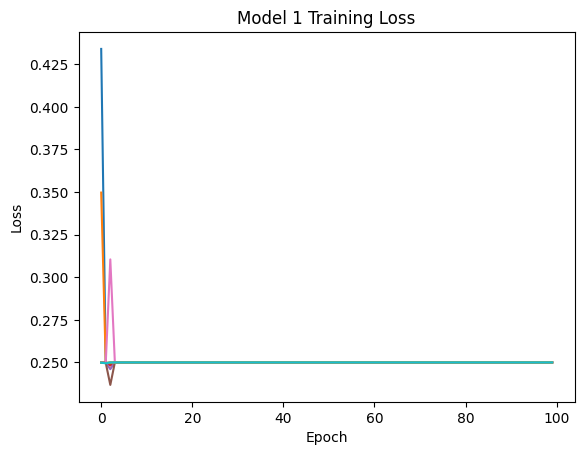

In [97]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

# Identify categorical and continuous features
categorical_cols = ['State']
continuous_cols = X.columns.difference(categorical_cols).tolist()

# Preprocessor for later models
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), continuous_cols),
        ('cat', OneHotEncoder(), categorical_cols)
    ])

# Model 1: No preprocessing
X_train_raw = X_train.values
X_test_raw = X_test.values

# Initialize and train model
tlp = TLPVectorizedMiniBatch(n_hidden=30, epochs=100, eta=0.001, minibatches=10)
tlp.fit(X_train_raw, y_train)
y_pred = tlp.predict(X_test_raw)
print(f"Model 1 Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Plot training loss
import matplotlib.pyplot as plt
plt.plot(tlp.cost_)
plt.title("Model 1 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Model 2 Accuracy: 0.7266


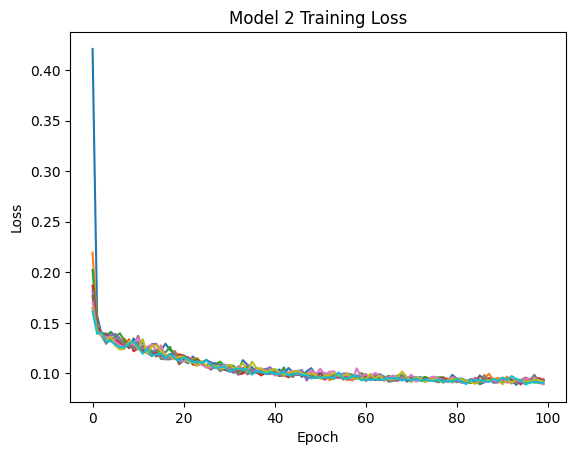

In [98]:
# Normalize continuous features
preprocessor_num = ColumnTransformer([('num', StandardScaler(), continuous_cols)])
X_train_norm = preprocessor_num.fit_transform(X_train)
X_test_norm = preprocessor_num.transform(X_test)

# Train model
tlp_norm = TLPVectorizedMiniBatch(n_hidden=30, epochs=100, eta=0.001, minibatches=10)
tlp_norm.fit(X_train_norm, y_train)
y_pred_norm = tlp_norm.predict(X_test_norm)
print(f"Model 2 Accuracy: {accuracy_score(y_test, y_pred_norm):.4f}")

# Plot loss
plt.plot(tlp_norm.cost_)
plt.title("Model 2 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Model 3 Accuracy: 0.7261


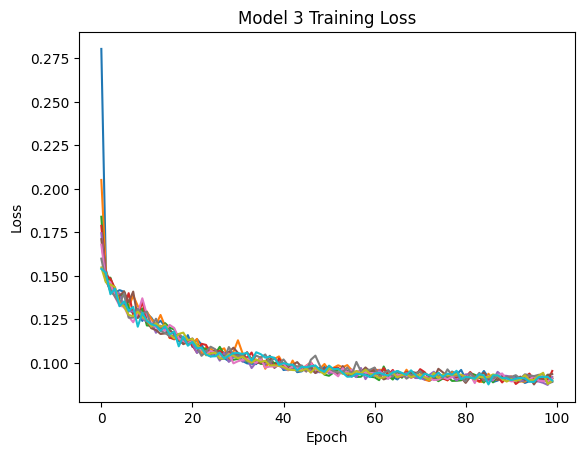

In [99]:
# Apply full preprocessing
X_train_full = preprocessor.fit_transform(X_train)
X_test_full = preprocessor.transform(X_test)

# Train model
tlp_full = TLPVectorizedMiniBatch(n_hidden=30, epochs=100, eta=0.001, minibatches=10)
tlp_full.fit(X_train_full, y_train)
y_pred_full = tlp_full.predict(X_test_full)
print(f"Model 3 Accuracy: {accuracy_score(y_test, y_pred_full):.4f}")

# Plot loss
plt.plot(tlp_full.cost_)
plt.title("Model 3 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 3. Modeling with Deeper Networks

In [73]:
class ThreeLayerPerceptron(TLPVectorizedMiniBatch):
    def __init__(self, n_hidden1=30, n_hidden2=20, **kwargs):
        super().__init__(**kwargs)
        self.n_hidden1 = n_hidden1  # First hidden layer size
        self.n_hidden2 = n_hidden2  # Second hidden layer size
        self.grad_magnitudes = {'W1': [], 'W2': [], 'W3': []}  # Track gradient magnitudes

    def _initialize_weights(self):
        # Glorot initialization for all layers
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2 / self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2 / self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_output_, self.n_hidden2) * np.sqrt(2 / self.n_hidden2)
        b3 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, b1, b2, b3

    def _feedforward(self, X, W1, W2, W3, b1, b2, b3):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        Z3 = W3 @ A3 + b3
        A4 = self._sigmoid(Z3)
        return A1, Z1, A2, Z2, A3, Z3, A4

    def _get_gradient(self, A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, W1, W2, W3):
        # Backpropagation for three layers
        V3 = -2 * (Y_enc - A4) * A4 * (1 - A4)  # Output layer gradient
        V2 = A3 * (1 - A3) * (W3.T @ V3)        # Hidden layer 2 gradient
        V1 = A2 * (1 - A2) * (W2.T @ V2)        # Hidden layer 1 gradient

        gradW3 = V3 @ A3.T
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T

        # Track gradient magnitudes (L2 norm)
        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))

        return gradW1, gradW2, gradW3, V1.sum(axis=1).reshape(-1, 1), V2.sum(axis=1).reshape(-1, 1), V3.sum(axis=1).reshape(-1, 1)

    def fit(self, X, y, print_progress=False):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)

        # Initialize weights (now 6 values)
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.b1, self.b2, self.b3 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):
            # Feedforward
            A1, Z1, A2, Z2, A3, Z3, A4 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.b1, self.b2, self.b3
            )

            # Cost
            cost = self._cost(A4, Y_enc, self.W1, self.W2, self.W3)
            self.cost_.append(cost)

            # Backpropagation
            gradW1, gradW2, gradW3, gradb1, gradb2, gradb3 = self._get_gradient(
                A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, self.W1, self.W2, self.W3
            )

            # Update weights with momentum (from parent class)
            self.W1 -= self.eta * gradW1
            self.W2 -= self.eta * gradW2
            self.W3 -= self.eta * gradW3
            self.b1 -= self.eta * gradb1
            self.b2 -= self.eta * gradb2
            self.b3 -= self.eta * gradb3

        return self

    def predict(self, X):
        _, _, _, _, _, _, A4 = self._feedforward(
            X, self.W1, self.W2, self.W3, self.b1, self.b2, self.b3
        )
        y_pred = np.argmax(A4, axis=0)
        return y_pred
        
    def _cost(self, A4, Y_enc, W1, W2, W3):
        """Compute cost with L2 regularization for 3 layers"""
        cost = np.mean((Y_enc - A4) ** 2)
        L2_term = self._L2_reg(self.l2_C, W1, W2, W3)  # Updated L2 regularization
        return cost + L2_term

    @staticmethod
    def _L2_reg(lambda_, W1, W2, W3):
        """L2 regularization term for 3 layers"""
        return lambda_ * (np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2))

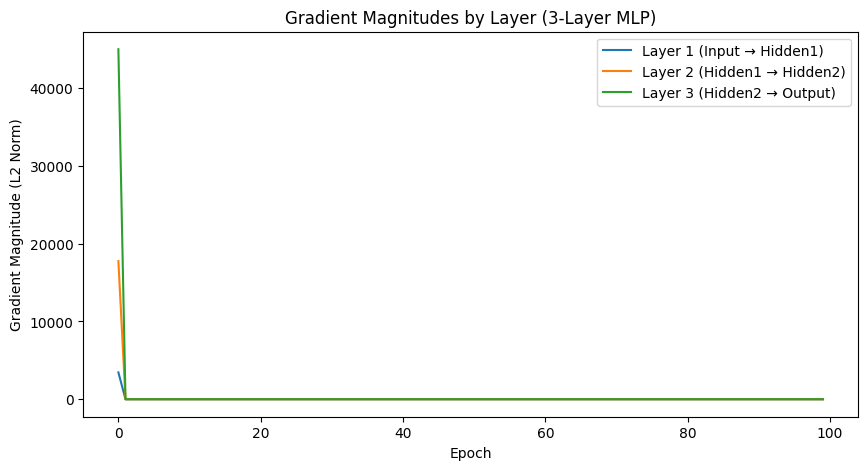

3-Layer MLP Accuracy: 0.2507


In [74]:
# Train 3-layer MLP
tlp3 = ThreeLayerPerceptron(n_hidden1=30, n_hidden2=20, epochs=100, eta=0.001)
tlp3.fit(X_train_full, y_train)

# Plot gradient magnitudes
plt.figure(figsize=(10, 5))
plt.plot(tlp3.grad_magnitudes['W1'], label='Layer 1 (Input → Hidden1)')
plt.plot(tlp3.grad_magnitudes['W2'], label='Layer 2 (Hidden1 → Hidden2)')
plt.plot(tlp3.grad_magnitudes['W3'], label='Layer 3 (Hidden2 → Output)')
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.title("Gradient Magnitudes by Layer (3-Layer MLP)")
plt.legend()
plt.show()

# Evaluate
y_pred = tlp3.predict(X_test_full)
print(f"3-Layer MLP Accuracy: {accuracy_score(y_test, y_pred):.4f}")

In [75]:
class FourLayerPerceptron(TLPVectorizedMiniBatch):
    def __init__(self, n_hidden1=30, n_hidden2=20, n_hidden3=15, **kwargs):
        super().__init__(**kwargs)
        self.n_hidden1 = n_hidden1  # First hidden layer
        self.n_hidden2 = n_hidden2  # Second hidden layer
        self.n_hidden3 = n_hidden3  # Third hidden layer
        self.grad_magnitudes = {'W1': [], 'W2': [], 'W3': [], 'W4': []}  # Track gradients

    def _initialize_weights(self):
        # Glorot initialization for all layers
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2 / self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2 / self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_hidden3, self.n_hidden2) * np.sqrt(2 / self.n_hidden2)
        b3 = np.zeros((self.n_hidden3, 1))
        W4 = np.random.randn(self.n_output_, self.n_hidden3) * np.sqrt(2 / self.n_hidden3)
        b4 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, W4, b1, b2, b3, b4

    def _feedforward(self, X, W1, W2, W3, W4, b1, b2, b3, b4):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        Z3 = W3 @ A3 + b3
        A4 = self._sigmoid(Z3)
        Z4 = W4 @ A4 + b4
        A5 = self._sigmoid(Z4)
        return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5

    def _get_gradient(self, A1, A2, A3, A4, A5, Z1, Z2, Z3, Z4, Y_enc, W1, W2, W3, W4):
        # Output layer gradient
        V4 = -2 * (Y_enc - A5) * A5 * (1 - A5)
        # Hidden layer 3 gradient
        V3 = A4 * (1 - A4) * (W4.T @ V4)
        # Hidden layer 2 gradient
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        # Hidden layer 1 gradient
        V1 = A2 * (1 - A2) * (W2.T @ V2)

        # Compute gradients for weights
        gradW4 = V4 @ A4.T
        gradW3 = V3 @ A3.T
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T

        # Track gradient magnitudes (L2 norm)
        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))
        self.grad_magnitudes['W4'].append(np.linalg.norm(gradW4))

        # Gradients for biases
        gradb4 = np.sum(V4, axis=1).reshape(-1, 1)
        gradb3 = np.sum(V3, axis=1).reshape(-1, 1)
        gradb2 = np.sum(V2, axis=1).reshape(-1, 1)
        gradb1 = np.sum(V1, axis=1).reshape(-1, 1)

        return gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4

    def _cost(self, A5, Y_enc, W1, W2, W3, W4):
        """Compute cost with L2 regularization for 4 layers"""
        cost = np.mean((Y_enc - A5) ** 2)
        L2_term = self.l2_C * (np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2) + np.mean(W4**2))
        return cost + L2_term

    def fit(self, X, y, print_progress=False):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)

        # Initialize weights and biases
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):
            # Feedforward
            A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4
            )

            # Compute cost
            cost = self._cost(A5, Y_enc, self.W1, self.W2, self.W3, self.W4)
            self.cost_.append(cost)

            # Backpropagation
            gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4 = self._get_gradient(
                A1, A2, A3, A4, A5, Z1, Z2, Z3, Z4, Y_enc, self.W1, self.W2, self.W3, self.W4
            )

            # Update weights and biases
            self.W1 -= self.eta * gradW1
            self.W2 -= self.eta * gradW2
            self.W3 -= self.eta * gradW3
            self.W4 -= self.eta * gradW4
            self.b1 -= self.eta * gradb1
            self.b2 -= self.eta * gradb2
            self.b3 -= self.eta * gradb3
            self.b4 -= self.eta * gradb4

        return self

    def predict(self, X):
        _, _, _, _, _, _, _, _, A5 = self._feedforward(
            X, self.W1, self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4
        )
        return np.argmax(A5, axis=0)

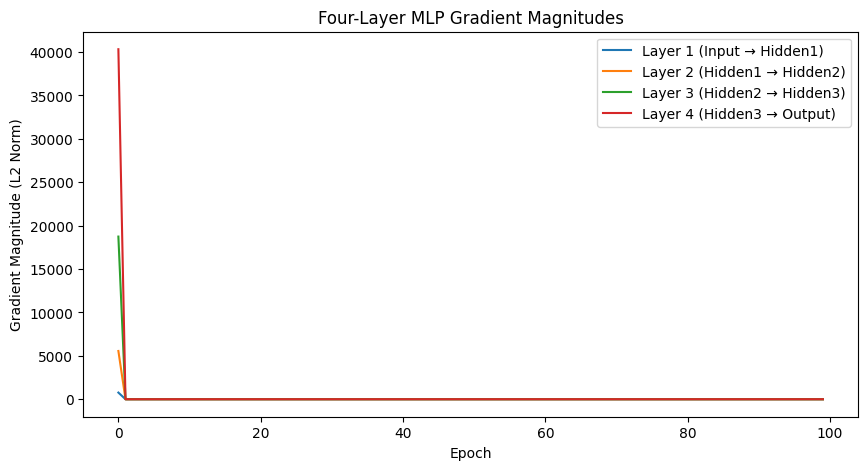

4-Layer MLP Accuracy: 0.2496


In [76]:
# Train 4-layer MLP
tlp4 = FourLayerPerceptron(n_hidden1=30, n_hidden2=20, n_hidden3=15, epochs=100, eta=0.001)
tlp4.fit(X_train_full, y_train)

# Plot gradient magnitudes
plt.figure(figsize=(10, 5))
plt.plot(tlp4.grad_magnitudes['W1'], label='Layer 1 (Input → Hidden1)')
plt.plot(tlp4.grad_magnitudes['W2'], label='Layer 2 (Hidden1 → Hidden2)')
plt.plot(tlp4.grad_magnitudes['W3'], label='Layer 3 (Hidden2 → Hidden3)')
plt.plot(tlp4.grad_magnitudes['W4'], label='Layer 4 (Hidden3 → Output)')
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.title("Four-Layer MLP Gradient Magnitudes")
plt.legend()
plt.show()

# Evaluate
y_pred = tlp4.predict(X_test_full)
print(f"4-Layer MLP Accuracy: {accuracy_score(y_test, y_pred):.4f}")

In [77]:
class FiveLayerPerceptron(FourLayerPerceptron):
    def __init__(self, n_hidden4=10, **kwargs):
        super().__init__(**kwargs)
        self.n_hidden4 = n_hidden4  # Fourth hidden layer
        self.grad_magnitudes['W5'] = []  # Track fifth layer gradients

    def _initialize_weights(self):
        # Glorot initialization for all layers
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2 / self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2 / self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_hidden3, self.n_hidden2) * np.sqrt(2 / self.n_hidden2)
        b3 = np.zeros((self.n_hidden3, 1))
        W4 = np.random.randn(self.n_hidden4, self.n_hidden3) * np.sqrt(2 / self.n_hidden3)
        b4 = np.zeros((self.n_hidden4, 1))
        W5 = np.random.randn(self.n_output_, self.n_hidden4) * np.sqrt(2 / self.n_hidden4)
        b5 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, W4, W5, b1, b2, b3, b4, b5

    def _feedforward(self, X, W1, W2, W3, W4, W5, b1, b2, b3, b4, b5):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        Z3 = W3 @ A3 + b3
        A4 = self._sigmoid(Z3)
        Z4 = W4 @ A4 + b4
        A5 = self._sigmoid(Z4)
        Z5 = W5 @ A5 + b5
        A6 = self._sigmoid(Z5)
        return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6

    def _get_gradient(self, A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, W1, W2, W3, W4, W5):
        # Output layer gradient
        V5 = -2 * (Y_enc - A6) * A6 * (1 - A6)
        # Hidden layer 4 gradient
        V4 = A5 * (1 - A5) * (W5.T @ V5)
        # Hidden layer 3 gradient
        V3 = A4 * (1 - A4) * (W4.T @ V4)
        # Hidden layer 2 gradient
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        # Hidden layer 1 gradient
        V1 = A2 * (1 - A2) * (W2.T @ V2)

        # Compute gradients for weights
        gradW5 = V5 @ A5.T
        gradW4 = V4 @ A4.T
        gradW3 = V3 @ A3.T
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T

        # Track gradient magnitudes
        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))
        self.grad_magnitudes['W4'].append(np.linalg.norm(gradW4))
        self.grad_magnitudes['W5'].append(np.linalg.norm(gradW5))

        # Gradients for biases
        gradb5 = np.sum(V5, axis=1).reshape(-1, 1)
        gradb4 = np.sum(V4, axis=1).reshape(-1, 1)
        gradb3 = np.sum(V3, axis=1).reshape(-1, 1)
        gradb2 = np.sum(V2, axis=1).reshape(-1, 1)
        gradb1 = np.sum(V1, axis=1).reshape(-1, 1)

        return gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5

    def _cost(self, A6, Y_enc, W1, W2, W3, W4, W5):
        """Compute cost with L2 regularization for 5 layers"""
        cost = np.mean((Y_enc - A6) ** 2)
        L2_term = self.l2_C * np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2) + np.mean(W4**2) + np.mean(W5**2)
        return cost + L2_term

    def fit(self, X, y, print_progress=False):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)

        # Initialize weights and biases
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):
            # Feedforward
            A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5
            )

            # Compute cost
            cost = self._cost(A6, Y_enc, self.W1, self.W2, self.W3, self.W4, self.W5)
            self.cost_.append(cost)

            # Backpropagation
            (self.gradW1, self.gradW2, self.gradW3, self.gradW4, self.gradW5,
             self.gradb1, self.gradb2, self.gradb3, self.gradb4, self.gradb5) = self._get_gradient(
                A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, 
                self.W1, self.W2, self.W3, self.W4, self.W5
            )

            # Update weights using vanilla SGD (to be overridden in child classes)
            self.W1 -= self.eta * self.gradW1
            self.W2 -= self.eta * self.gradW2
            self.W3 -= self.eta * self.gradW3
            self.W4 -= self.eta * self.gradW4
            self.W5 -= self.eta * self.gradW5
            self.b1 -= self.eta * self.gradb1
            self.b2 -= self.eta * self.gradb2
            self.b3 -= self.eta * self.gradb3
            self.b4 -= self.eta * self.gradb4
            self.b5 -= self.eta * self.gradb5

        return self

    def predict(self, X):
        _, _, _, _, _, _, _, _, _, _, A6 = self._feedforward(
            X, self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5
        )
        return np.argmax(A6, axis=0)

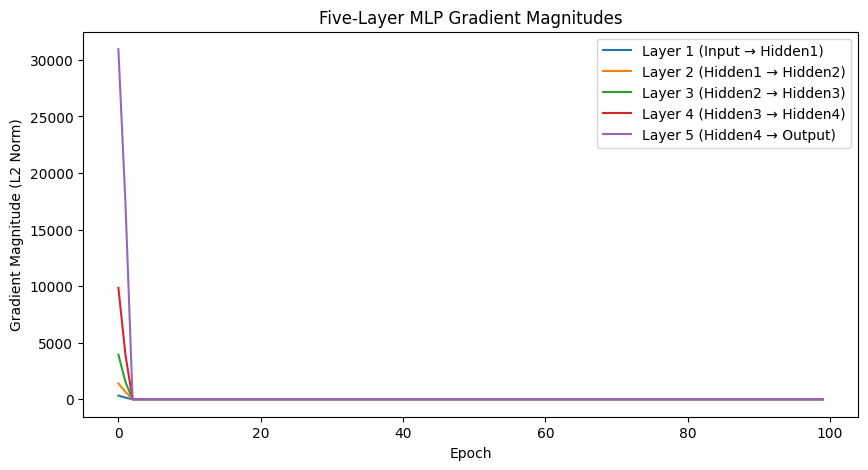

5-Layer MLP Accuracy: 0.2499


In [78]:
# Train 5-layer MLP
tlp5 = FiveLayerPerceptron(n_hidden1=30, n_hidden2=20, n_hidden3=15, n_hidden4=10, epochs=100, eta=0.001)
tlp5.fit(X_train_full, y_train)

# Plot gradient magnitudes
plt.figure(figsize=(10, 5))
plt.plot(tlp5.grad_magnitudes['W1'], label='Layer 1 (Input → Hidden1)')
plt.plot(tlp5.grad_magnitudes['W2'], label='Layer 2 (Hidden1 → Hidden2)')
plt.plot(tlp5.grad_magnitudes['W3'], label='Layer 3 (Hidden2 → Hidden3)')
plt.plot(tlp5.grad_magnitudes['W4'], label='Layer 4 (Hidden3 → Hidden4)')
plt.plot(tlp5.grad_magnitudes['W5'], label='Layer 5 (Hidden4 → Output)')
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.title("Five-Layer MLP Gradient Magnitudes")
plt.legend()
plt.show()

# Evaluate
y_pred = tlp5.predict(X_test_full)
print(f"5-Layer MLP Accuracy: {accuracy_score(y_test, y_pred):.4f}")

In [88]:
class FiveLayerMLPWithRMSProp(FiveLayerPerceptron):
    def __init__(self, rho=0.9, epsilon=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.rho = rho
        self.epsilon = epsilon
        self.cache = {}  # Stores squared gradients for each parameter

    def fit(self, X, y, print_progress=False):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)

        # Initialize weights and cache
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5 = self._initialize_weights()

        # Initialize cache for RMSProp
        for param in ['W1', 'W2', 'W3', 'W4', 'W5', 'b1', 'b2', 'b3', 'b4', 'b5']:
            self.cache[param] = np.zeros_like(getattr(self, param))

        self.cost_ = []
        for epoch in range(self.epochs):
            # Feedforward
            A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.W4, self.W5, 
                self.b1, self.b2, self.b3, self.b4, self.b5
            )

            # Compute cost
            cost = self._cost(A6, Y_enc, self.W1, self.W2, self.W3, self.W4, self.W5)
            self.cost_.append(cost)

            # Backpropagation (gradients stored in self.gradW1, self.gradb1, etc.)
            (self.gradW1, self.gradW2, self.gradW3, self.gradW4, self.gradW5,
             self.gradb1, self.gradb2, self.gradb3, self.gradb4, self.gradb5) = self._get_gradient(
                A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, 
                self.W1, self.W2, self.W3, self.W4, self.W5
            )

            # RMSProp updates
            for param in ['W1', 'W2', 'W3', 'W4', 'W5', 'b1', 'b2', 'b3', 'b4', 'b5']:
                grad = getattr(self, f'grad{param}')
                self.cache[param] = self.rho * self.cache[param] + (1 - self.rho) * grad**2
                adjusted_grad = grad / (np.sqrt(self.cache[param]) + self.epsilon)
                
                # Correct: Assign new value using setattr
                new_value = getattr(self, param) - self.eta * adjusted_grad
                setattr(self, param, new_value)

        return self

In [89]:
# Train with RMSProp
tlp5_rms = FiveLayerMLPWithRMSProp(
    n_hidden1=30, n_hidden2=20, n_hidden3=15, n_hidden4=10, epochs=100, eta=0.001, rho=0.9
)
tlp5_rms.fit(X_train_full, y_train)

# Evaluate
y_pred_rms = tlp5_rms.predict(X_test_full)
print(f"5-Layer MLP with RMSProp Accuracy: {accuracy_score(y_test, y_pred_rms):.4f}")

5-Layer MLP with RMSProp Accuracy: 0.2507


In [86]:
class FiveLayerMLPWithAdaM(FiveLayerPerceptron):
    def __init__(self, beta1=0.9, beta2=0.999, epsilon=1e-8, **kwargs):
        super().__init__(**kwargs)
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = {}  # First moment (momentum)
        self.v = {}  # Second moment (RMS)

    def fit(self, X, y, print_progress=False):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)

        # Initialize weights and moments
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5 = self._initialize_weights()

        # Initialize moments for AdaM
        for param in ['W1', 'W2', 'W3', 'W4', 'W5', 'b1', 'b2', 'b3', 'b4', 'b5']:
            self.m[param] = np.zeros_like(getattr(self, param))
            self.v[param] = np.zeros_like(getattr(self, param))

        self.cost_ = []
        for t in range(1, self.epochs + 1):
            # Feedforward
            A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.W4, self.W5, 
                self.b1, self.b2, self.b3, self.b4, self.b5
            )

            # Compute cost
            cost = self._cost(A6, Y_enc, self.W1, self.W2, self.W3, self.W4, self.W5)
            self.cost_.append(cost)

            # Backpropagation (gradients stored in self.gradW1, self.gradb1, etc.)
            (self.gradW1, self.gradW2, self.gradW3, self.gradW4, self.gradW5,
             self.gradb1, self.gradb2, self.gradb3, self.gradb4, self.gradb5) = self._get_gradient(
                A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, 
                self.W1, self.W2, self.W3, self.W4, self.W5
            )

            # AdaM updates
            for param in ['W1', 'W2', 'W3', 'W4', 'W5', 'b1', 'b2', 'b3', 'b4', 'b5']:
                grad = getattr(self, f'grad{param}')
                self.m[param] = self.beta1 * self.m[param] + (1 - self.beta1) * grad
                self.v[param] = self.beta2 * self.v[param] + (1 - self.beta2) * grad**2
                m_hat = self.m[param] / (1 - self.beta1**t)
                v_hat = self.v[param] / (1 - self.beta2**t)
                adjusted_grad = m_hat / (np.sqrt(v_hat) + self.epsilon)
                
                # Correct: Assign new value using setattr
                new_value = getattr(self, param) - self.eta * adjusted_grad
                setattr(self, param, new_value)


        return self

In [87]:
# Train with AdaM
tlp5_adam = FiveLayerMLPWithAdaM(
    n_hidden1=30, n_hidden2=20, n_hidden3=15, n_hidden4=10, epochs=100, eta=0.001
)
tlp5_adam.fit(X_train_full, y_train)

# Evaluate
y_pred_adam = tlp5_adam.predict(X_test_full)
print(f"5-Layer MLP with AdaM Accuracy: {accuracy_score(y_test, y_pred_adam):.4f}")

5-Layer MLP with AdaM Accuracy: 0.2496


3-Layer MLP Accuracy: 0.2499


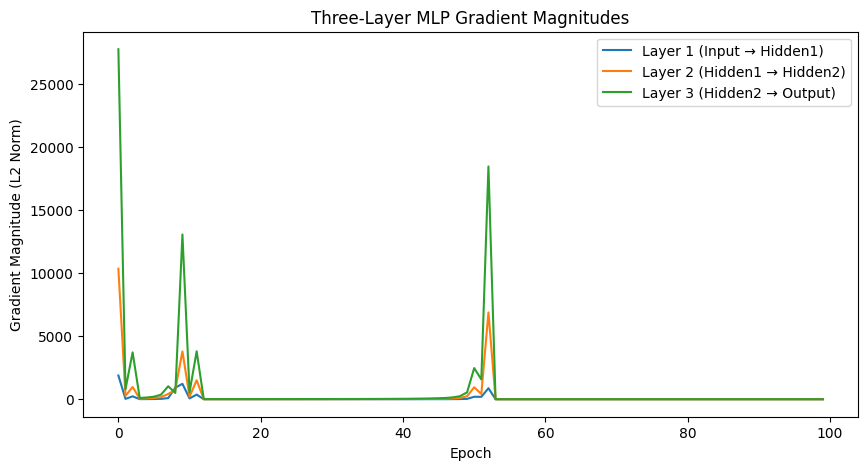

In [91]:
# Base class (modified for gradient tracking)
class ThreeLayerPerceptron:
    def __init__(self, n_hidden1=30, n_hidden2=20, C=0.0, epochs=100, eta=0.001, random_state=None):
        np.random.seed(random_state)
        self.n_hidden1 = n_hidden1
        self.n_hidden2 = n_hidden2
        self.l2_C = C
        self.epochs = epochs
        self.eta = eta
        self.grad_magnitudes = {'W1': [], 'W2': [], 'W3': []}

    def _encode_labels(self, y):
        onehot = pd.get_dummies(y).values.T
        return onehot

    def _initialize_weights(self):
        # Glorot initialization
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2 / self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2 / self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_output_, self.n_hidden2) * np.sqrt(2 / self.n_hidden2)
        b3 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, b1, b2, b3

    def _sigmoid(self, z):
        return expit(z)

    def _feedforward(self, X, W1, W2, W3, b1, b2, b3):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        Z3 = W3 @ A3 + b3
        A4 = self._sigmoid(Z3)
        return A1, Z1, A2, Z2, A3, Z3, A4

    def _get_gradient(self, A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, W1, W2, W3):
        V3 = -2 * (Y_enc - A4) * A4 * (1 - A4)
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        V1 = A2 * (1 - A2) * (W2.T @ V2)

        gradW3 = V3 @ A3.T
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T

        # Track gradient magnitudes (L2 norm)
        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))

        return gradW1, gradW2, gradW3, V1.sum(axis=1).reshape(-1, 1), V2.sum(axis=1).reshape(-1, 1), V3.sum(axis=1).reshape(-1, 1)

    def _cost(self, A4, Y_enc, W1, W2, W3):
        cost = np.mean((Y_enc - A4) ** 2)
        L2_term = self.l2_C * np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2)
        return cost + L2_term

    def fit(self, X, y):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y_data)
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.b1, self.b2, self.b3 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):
            A1, Z1, A2, Z2, A3, Z3, A4 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.b1, self.b2, self.b3
            )
            cost = self._cost(A4, Y_enc, self.W1, self.W2, self.W3)
            self.cost_.append(cost)

            gradW1, gradW2, gradW3, gradb1, gradb2, gradb3 = self._get_gradient(
                A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, self.W1, self.W2, self.W3
            )

            # Update weights
            self.W1 -= self.eta * gradW1
            self.W2 -= self.eta * gradW2
            self.W3 -= self.eta * gradW3
            self.b1 -= self.eta * gradb1
            self.b2 -= self.eta * gradb2
            self.b3 -= self.eta * gradb3

        return self

    def predict(self, X):
        _, _, _, _, _, _, A4 = self._feedforward(X, self.W1, self.W2, self.W3, self.b1, self.b2, self.b3)
        return np.argmax(A4, axis=0)

# Train and evaluate
tlp3 = ThreeLayerPerceptron(n_hidden1=30, n_hidden2=20, epochs=100, eta=0.001)
tlp3.fit(X_train_full, y_train)
y_pred = tlp3.predict(X_test_full)
print(f"3-Layer MLP Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Plot gradients
plt.figure(figsize=(10, 5))
plt.plot(tlp3.grad_magnitudes['W1'], label='Layer 1 (Input → Hidden1)')
plt.plot(tlp3.grad_magnitudes['W2'], label='Layer 2 (Hidden1 → Hidden2)')
plt.plot(tlp3.grad_magnitudes['W3'], label='Layer 3 (Hidden2 → Output)')
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.title("Three-Layer MLP Gradient Magnitudes")
plt.legend()
plt.show()

4-Layer MLP Accuracy: 0.2496


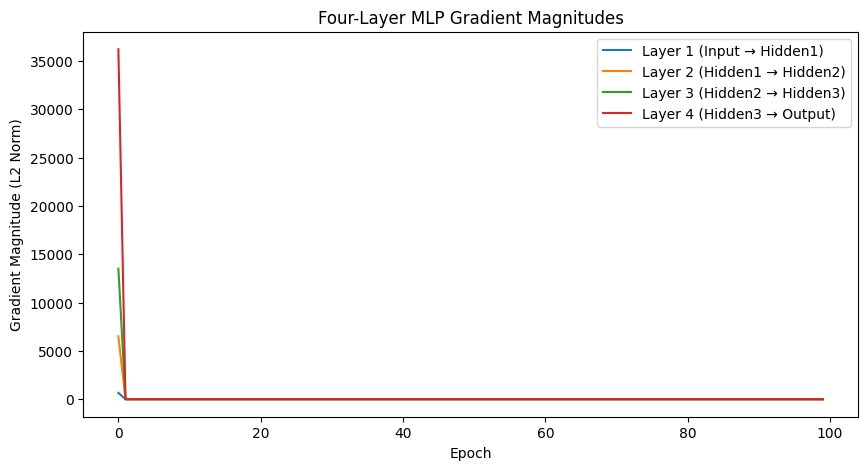

In [92]:
class FourLayerPerceptron(ThreeLayerPerceptron):
    def __init__(self, n_hidden3=15, **kwargs):
        super().__init__(**kwargs)
        self.n_hidden3 = n_hidden3
        self.grad_magnitudes['W4'] = []

    def _initialize_weights(self):
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2 / self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2 / self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_hidden3, self.n_hidden2) * np.sqrt(2 / self.n_hidden2)
        b3 = np.zeros((self.n_hidden3, 1))
        W4 = np.random.randn(self.n_output_, self.n_hidden3) * np.sqrt(2 / self.n_hidden3)
        b4 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, W4, b1, b2, b3, b4

    def _feedforward(self, X, W1, W2, W3, W4, b1, b2, b3, b4):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        Z3 = W3 @ A3 + b3
        A4 = self._sigmoid(Z3)
        Z4 = W4 @ A4 + b4
        A5 = self._sigmoid(Z4)
        return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5

    def _get_gradient(self, A1, A2, A3, A4, A5, Z1, Z2, Z3, Z4, Y_enc, W1, W2, W3, W4):
        V4 = -2 * (Y_enc - A5) * A5 * (1 - A5)
        V3 = A4 * (1 - A4) * (W4.T @ V4)
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        V1 = A2 * (1 - A2) * (W2.T @ V2)

        gradW4 = V4 @ A4.T
        gradW3 = V3 @ A3.T
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T

        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))
        self.grad_magnitudes['W4'].append(np.linalg.norm(gradW4))

        return gradW1, gradW2, gradW3, gradW4, V1.sum(axis=1).reshape(-1, 1), V2.sum(axis=1).reshape(-1, 1), V3.sum(axis=1).reshape(-1, 1), V4.sum(axis=1).reshape(-1, 1)

    def _cost(self, A5, Y_enc, W1, W2, W3, W4):
        cost = np.mean((Y_enc - A5) ** 2)
        L2_term = self.l2_C * np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2) + np.mean(W4**2)
        return cost + L2_term

    def fit(self, X, y):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y_data)
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):
            A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4
            )
            cost = self._cost(A5, Y_enc, self.W1, self.W2, self.W3, self.W4)
            self.cost_.append(cost)

            gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4 = self._get_gradient(
                A1, A2, A3, A4, A5, Z1, Z2, Z3, Z4, Y_enc, self.W1, self.W2, self.W3, self.W4
            )

            self.W1 -= self.eta * gradW1
            self.W2 -= self.eta * gradW2
            self.W3 -= self.eta * gradW3
            self.W4 -= self.eta * gradW4
            self.b1 -= self.eta * gradb1
            self.b2 -= self.eta * gradb2
            self.b3 -= self.eta * gradb3
            self.b4 -= self.eta * gradb4

        return self

    def predict(self, X):
        _, _, _, _, _, _, _, _, A5 = self._feedforward(
            X, self.W1, self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4
        )
        return np.argmax(A5, axis=0)

# Train and evaluate
tlp4 = FourLayerPerceptron(n_hidden1=30, n_hidden2=20, n_hidden3=15, epochs=100, eta=0.001)
tlp4.fit(X_train_full, y_train)
y_pred = tlp4.predict(X_test_full)
print(f"4-Layer MLP Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Plot gradients
plt.figure(figsize=(10, 5))
plt.plot(tlp4.grad_magnitudes['W1'], label='Layer 1 (Input → Hidden1)')
plt.plot(tlp4.grad_magnitudes['W2'], label='Layer 2 (Hidden1 → Hidden2)')
plt.plot(tlp4.grad_magnitudes['W3'], label='Layer 3 (Hidden2 → Hidden3)')
plt.plot(tlp4.grad_magnitudes['W4'], label='Layer 4 (Hidden3 → Output)')
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.title("Four-Layer MLP Gradient Magnitudes")
plt.legend()
plt.show()

5-Layer MLP Accuracy: 0.2496


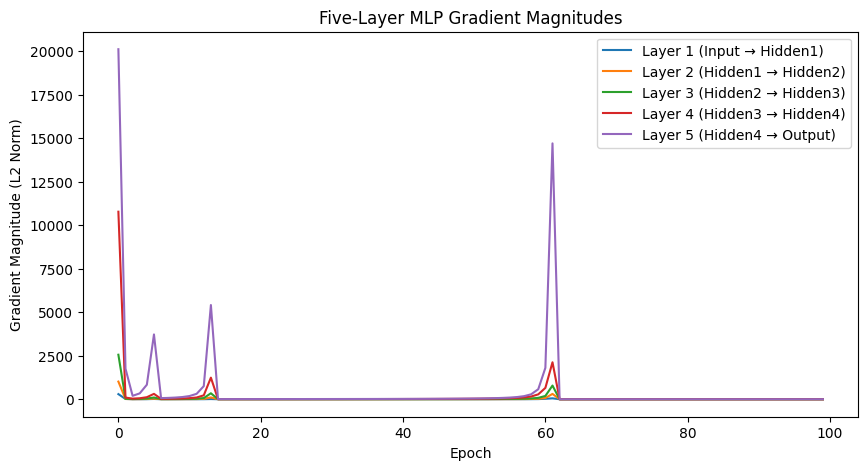

In [93]:
class FiveLayerPerceptron(FourLayerPerceptron):
    def __init__(self, n_hidden4=10, **kwargs):
        super().__init__(**kwargs)
        self.n_hidden4 = n_hidden4
        self.grad_magnitudes['W5'] = []

    def _initialize_weights(self):
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2 / self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2 / self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_hidden3, self.n_hidden2) * np.sqrt(2 / self.n_hidden2)
        b3 = np.zeros((self.n_hidden3, 1))
        W4 = np.random.randn(self.n_hidden4, self.n_hidden3) * np.sqrt(2 / self.n_hidden3)
        b4 = np.zeros((self.n_hidden4, 1))
        W5 = np.random.randn(self.n_output_, self.n_hidden4) * np.sqrt(2 / self.n_hidden4)
        b5 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, W4, W5, b1, b2, b3, b4, b5

    def _feedforward(self, X, W1, W2, W3, W4, W5, b1, b2, b3, b4, b5):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = self._sigmoid(Z1)
        Z2 = W2 @ A2 + b2
        A3 = self._sigmoid(Z2)
        Z3 = W3 @ A3 + b3
        A4 = self._sigmoid(Z3)
        Z4 = W4 @ A4 + b4
        A5 = self._sigmoid(Z4)
        Z5 = W5 @ A5 + b5
        A6 = self._sigmoid(Z5)
        return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6

    def _get_gradient(self, A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, W1, W2, W3, W4, W5):
        V5 = -2 * (Y_enc - A6) * A6 * (1 - A6)
        V4 = A5 * (1 - A5) * (W5.T @ V5)
        V3 = A4 * (1 - A4) * (W4.T @ V4)
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        V1 = A2 * (1 - A2) * (W2.T @ V2)

        gradW5 = V5 @ A5.T
        gradW4 = V4 @ A4.T
        gradW3 = V3 @ A3.T
        gradW2 = V2 @ A2.T
        gradW1 = V1 @ A1.T

        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))
        self.grad_magnitudes['W4'].append(np.linalg.norm(gradW4))
        self.grad_magnitudes['W5'].append(np.linalg.norm(gradW5))

        return gradW1, gradW2, gradW3, gradW4, gradW5, V1.sum(axis=1).reshape(-1, 1), V2.sum(axis=1).reshape(-1, 1), V3.sum(axis=1).reshape(-1, 1), V4.sum(axis=1).reshape(-1, 1), V5.sum(axis=1).reshape(-1, 1)

    def _cost(self, A6, Y_enc, W1, W2, W3, W4, W5):
        cost = np.mean((Y_enc - A6) ** 2)
        L2_term = self.l2_C * np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2) + np.mean(W4**2) + np.mean(W5**2)
        return cost + L2_term

    def fit(self, X, y):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y_data)
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5 = self._initialize_weights()

        self.cost_ = []
        for i in range(self.epochs):
            A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5
            )
            cost = self._cost(A6, Y_enc, self.W1, self.W2, self.W3, self.W4, self.W5)
            self.cost_.append(cost)

            (gradW1, gradW2, gradW3, gradW4, gradW5,
             gradb1, gradb2, gradb3, gradb4, gradb5) = self._get_gradient(
                A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, self.W1, self.W2, self.W3, self.W4, self.W5
            )

            self.W1 -= self.eta * gradW1
            self.W2 -= self.eta * gradW2
            self.W3 -= self.eta * gradW3
            self.W4 -= self.eta * gradW4
            self.W5 -= self.eta * gradW5
            self.b1 -= self.eta * gradb1
            self.b2 -= self.eta * gradb2
            self.b3 -= self.eta * gradb3
            self.b4 -= self.eta * gradb4
            self.b5 -= self.eta * gradb5

        return self

    def predict(self, X):
        _, _, _, _, _, _, _, _, _, _, A6 = self._feedforward(
            X, self.W1, self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5
        )
        return np.argmax(A6, axis=0)

# Train and evaluate vanilla 5-layer MLP
tlp5 = FiveLayerPerceptron(n_hidden1=30, n_hidden2=20, n_hidden3=15, n_hidden4=10, epochs=100, eta=0.001)
tlp5.fit(X_train_full, y_train)
y_pred = tlp5.predict(X_test_full)
print(f"5-Layer MLP Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Plot gradients
plt.figure(figsize=(10, 5))
plt.plot(tlp5.grad_magnitudes['W1'], label='Layer 1 (Input → Hidden1)')
plt.plot(tlp5.grad_magnitudes['W2'], label='Layer 2 (Hidden1 → Hidden2)')
plt.plot(tlp5.grad_magnitudes['W3'], label='Layer 3 (Hidden2 → Hidden3)')
plt.plot(tlp5.grad_magnitudes['W4'], label='Layer 4 (Hidden3 → Hidden4)')
plt.plot(tlp5.grad_magnitudes['W5'], label='Layer 5 (Hidden4 → Output)')
plt.xlabel("Epoch")
plt.ylabel("Gradient Magnitude (L2 Norm)")
plt.title("Five-Layer MLP Gradient Magnitudes")
plt.legend()
plt.show()

In [94]:
class ThreeLayerPerceptron(TwoLayerPerceptronBase):
    def __init__(self, n_hidden1=30, n_hidden2=20, **kwargs):
        super().__init__(**kwargs)
        self.n_hidden1 = n_hidden1  # First hidden layer
        self.n_hidden2 = n_hidden2  # Second hidden layer
        self.grad_magnitudes = {'W1': [], 'W2': [], 'W3': []}

    def _initialize_weights(self):
        # Glorot initialization for sigmoid
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2/(self.n_features_ + self.n_hidden1))
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2/(self.n_hidden1 + self.n_hidden2))
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_output_, self.n_hidden2) * np.sqrt(2/(self.n_hidden2 + self.n_output_))
        b3 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, b1, b2, b3

    def _feedforward(self, X):
        A1 = X.T
        Z1 = self.W1 @ A1 + self.b1
        A2 = self._sigmoid(Z1)
        Z2 = self.W2 @ A2 + self.b2
        A3 = self._sigmoid(Z2)
        Z3 = self.W3 @ A3 + self.b3
        A4 = self._sigmoid(Z3)
        return A1, Z1, A2, Z2, A3, Z3, A4

    def _backprop(self, Y_enc, A1, A2, A3, A4, Z1, Z2, Z3):
        # Output layer gradient
        V3 = -2 * (Y_enc - A4) * A4 * (1 - A4)
        # Hidden layer 2 gradient
        V2 = A3 * (1 - A3) * (self.W3.T @ V3)
        # Hidden layer 1 gradient
        V1 = A2 * (1 - A2) * (self.W2.T @ V2)

        # Calculate gradients
        gradW3 = V3 @ A3.T / A3.shape[1]
        gradW2 = V2 @ A2.T / A2.shape[1]
        gradW1 = V1 @ A1.T / A1.shape[1]

        # Track magnitudes
        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))

        return gradW1, gradW2, gradW3, V1, V2, V3

    def _cost(self, A4, Y_enc):
        mse = np.mean((Y_enc - A4)**2)
        reg_term = self.l2_C * (np.mean(self.W1**2) + np.mean(self.W2**2) + np.mean(self.W3**2))
        return mse + reg_term

    def fit(self, X, y):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y_data)
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.b1, self.b2, self.b3 = self._initialize_weights()

        self.cost_ = []
        for _ in range(self.epochs):
            # Forward pass
            A1, Z1, A2, Z2, A3, Z3, A4 = self._feedforward(X_data)

            # Backward pass
            gradW1, gradW2, gradW3, V1, V2, V3 = self._backprop(Y_enc, A1, A2, A3, A4, Z1, Z2, Z3)

            # Update parameters with regularization
            self.W1 -= self.eta * (gradW1 + self.l2_C * self.W1)
            self.W2 -= self.eta * (gradW2 + self.l2_C * self.W2)
            self.W3 -= self.eta * (gradW3 + self.l2_C * self.W3)
            
            # Update biases
            self.b1 -= self.eta * np.mean(V1, axis=1, keepdims=True)
            self.b2 -= self.eta * np.mean(V2, axis=1, keepdims=True)
            self.b3 -= self.eta * np.mean(V3, axis=1, keepdims=True)

            self.cost_.append(self._cost(A4, Y_enc))
        return self

    def predict(self, X):
        _, _, _, _, _, _, A4 = self._feedforward(X)
        return np.argmax(A4, axis=0)

3-Layer Accuracy: 0.3765


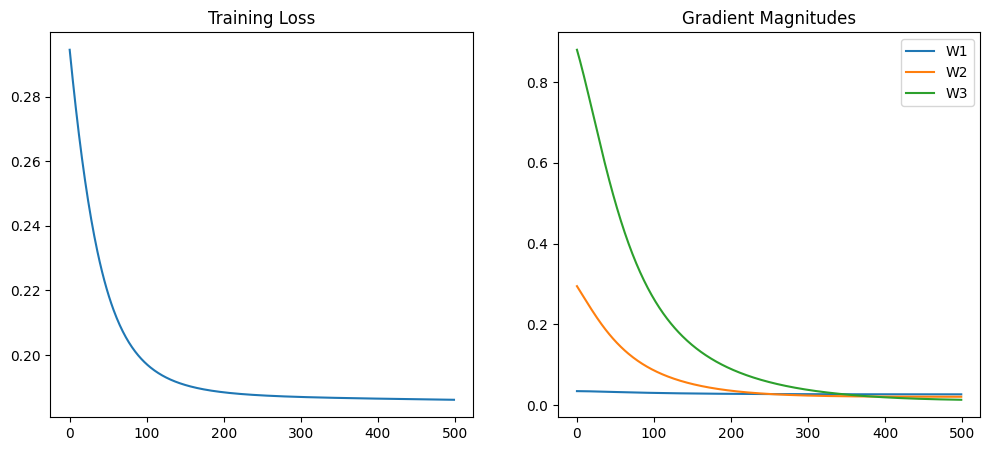

In [96]:
# Initialize and train
tlp3 = ThreeLayerPerceptron(n_hidden1=50, n_hidden2=30, epochs=500, eta=0.01, C=0.001)
tlp3.fit(X_train_full, y_train)

# Evaluate
y_pred = tlp3.predict(X_test_full)
print(f"3-Layer Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Plot training dynamics
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(tlp3.cost_)
plt.title("Training Loss")
plt.subplot(1,2,2)
plt.plot(tlp3.grad_magnitudes['W1'], label='W1')
plt.plot(tlp3.grad_magnitudes['W2'], label='W2')
plt.plot(tlp3.grad_magnitudes['W3'], label='W3')
plt.title("Gradient Magnitudes")
plt.legend()
plt.show()

In [105]:
import numpy as np
import sys
from scipy.special import expit

class ThreeLayerMLP(TLPVectorizedMiniBatch):
    def __init__(self, n_hidden1=30, n_hidden2=20, C=0.0, **kwargs):  # Changed to C
        super().__init__(C=C, **kwargs)  # Pass C to parent
        self.n_hidden1 = n_hidden1
        self.n_hidden2 = n_hidden2
        self.grad_magnitudes = {'W1': [], 'W2': [], 'W3': []}

    def _initialize_weights(self):
        # Glorot initialization for sigmoid
        lim1 = np.sqrt(6 / (self.n_features_ + self.n_hidden1))
        W1 = np.random.uniform(-lim1, lim1, (self.n_hidden1, self.n_features_))
        b1 = np.zeros((self.n_hidden1, 1))
        
        lim2 = np.sqrt(6 / (self.n_hidden1 + self.n_hidden2))
        W2 = np.random.uniform(-lim2, lim2, (self.n_hidden2, self.n_hidden1))
        b2 = np.zeros((self.n_hidden2, 1))
        
        lim3 = np.sqrt(6 / (self.n_hidden2 + self.n_output_))
        W3 = np.random.uniform(-lim3, lim3, (self.n_output_, self.n_hidden2))
        b3 = np.zeros((self.n_output_, 1))
        
        return W1, W2, W3, b1, b2, b3

    def _feedforward(self, X, W1, W2, W3, b1, b2, b3):
        A1 = X.T
        Z1 = W1 @ A1 + b1
        A2 = expit(Z1)
        Z2 = W2 @ A2 + b2
        A3 = expit(Z2)
        Z3 = W3 @ A3 + b3
        A4 = expit(Z3)
        return A1, Z1, A2, Z2, A3, Z3, A4

    def _get_gradient(self, A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, W1, W2, W3):
        # Output layer gradient
        V3 = -2 * (Y_enc - A4) * A4 * (1 - A4)
        # Hidden layer 2 gradient
        V2 = A3 * (1 - A3) * (W3.T @ V3)
        # Hidden layer 1 gradient
        V1 = A2 * (1 - A2) * (W2.T @ V2)

        gradW3 = V3 @ A3.T / A3.shape[1]
        gradW2 = V2 @ A2.T / A2.shape[1]
        gradW1 = V1 @ A1.T / A1.shape[1]

        # Track gradient magnitudes
        self.grad_magnitudes['W1'].append(np.linalg.norm(gradW1))
        self.grad_magnitudes['W2'].append(np.linalg.norm(gradW2))
        self.grad_magnitudes['W3'].append(np.linalg.norm(gradW3))

        return gradW1, gradW2, gradW3, V1.sum(axis=1, keepdims=True), V2.sum(axis=1, keepdims=True), V3.sum(axis=1, keepdims=True)

    def _cost(self, A4, Y_enc, W1, W2, W3):
        mse = np.mean((Y_enc - A4)**2)
        reg_term = self.l2_C * (np.mean(W1**2) + np.mean(W2**2) + np.mean(W3**2))
        return mse + reg_term

    def fit(self, X, y, print_progress=0):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # Initialize weights
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.b1, self.b2, self.b3 = self._initialize_weights()

        # Momentum buffers
        rho_W1_prev = np.zeros_like(self.W1)
        rho_W2_prev = np.zeros_like(self.W2)
        rho_W3_prev = np.zeros_like(self.W3)

        self.cost_ = []
        for k in range(self.epochs):
            # Adaptive learning rate
            eta = max(self.eta ** (1 + self.decrease_const * k), self.eta / 1000)

            if self.shuffle:
                ridx = np.random.permutation(y_data.shape[0])
                X_data, Y_enc = X_data[ridx], Y_enc[:, ridx]

            mini = np.array_split(range(y_data.shape[0]), self.minibatches)
            
            for idx in mini:
                # Feedforward
                A1, Z1, A2, Z2, A3, Z3, A4 = self._feedforward(
                    X_data[idx], self.W1, self.W2, self.W3, 
                    self.b1, self.b2, self.b3
                )

                # Compute cost
                cost = self._cost(A4, Y_enc[:, idx], self.W1, self.W2, self.W3)
                self.cost_.append(cost)

                # Backpropagation
                gradW1, gradW2, gradW3, gradb1, gradb2, gradb3 = self._get_gradient(
                    A1, A2, A3, A4, Z1, Z2, Z3, Y_enc[:, idx], 
                    self.W1, self.W2, self.W3
                )

                # Update with momentum
                rho_W1 = eta * gradW1 + self.alpha * rho_W1_prev
                rho_W2 = eta * gradW2 + self.alpha * rho_W2_prev
                rho_W3 = eta * gradW3 + self.alpha * rho_W3_prev
                
                self.W1 -= rho_W1 + self.l2_C * self.W1
                self.W2 -= rho_W2 + self.l2_C * self.W2
                self.W3 -= rho_W3 + self.l2_C * self.W3
                
                self.b1 -= eta * gradb1
                self.b2 -= eta * gradb2
                self.b3 -= eta * gradb3

                # Store momentum
                rho_W1_prev, rho_W2_prev, rho_W3_prev = rho_W1, rho_W2, rho_W3

        return self

    def predict(self, X):
        _, _, _, _, _, _, A4 = self._feedforward(X, self.W1, self.W2, self.W3, 
                                               self.b1, self.b2, self.b3)
        return np.argmax(A4, axis=0)

3-Layer Accuracy: 0.2507


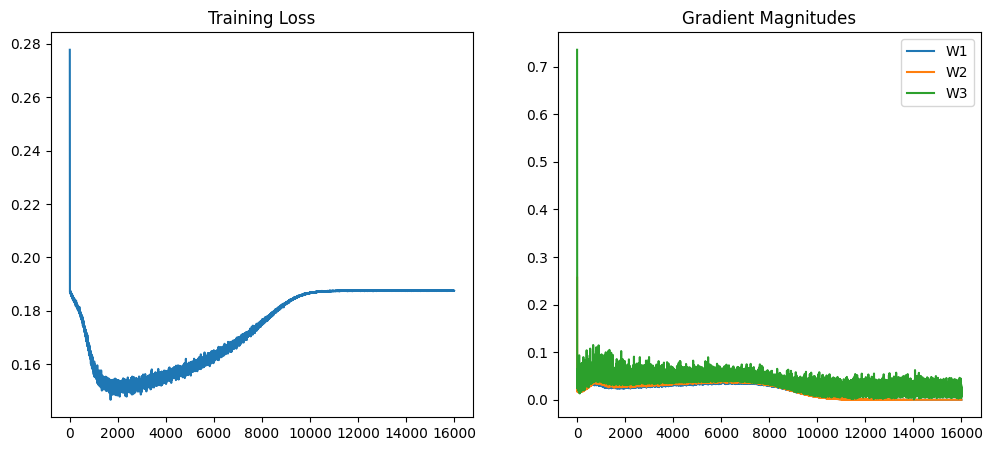

In [107]:
mlp3 = ThreeLayerMLP(
    n_hidden1=50,
    n_hidden2=30,
    C=0.001,  # Use C instead of l2_C
    epochs=500,
    eta=0.01,
    minibatches=32,
    alpha=0.9,
    decrease_const=1e-3
)
# Train on normalized data
mlp3.fit(X_train_full, y_train)

# Evaluate
y_pred = mlp3.predict(X_test_full)
print(f"3-Layer Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Plot training dynamics
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(mlp3.cost_)
plt.title("Training Loss")
plt.subplot(1,2,2)
plt.plot(mlp3.grad_magnitudes['W1'], label='W1')
plt.plot(mlp3.grad_magnitudes['W2'], label='W2')
plt.plot(mlp3.grad_magnitudes['W3'], label='W3')
plt.title("Gradient Magnitudes")
plt.legend()
plt.show()

In [109]:
import numpy as np
from scipy.special import softmax

class ThreeLayerMLPImproved(TLPVectorizedMiniBatch):
    def __init__(self, n_hidden1=256, n_hidden2=128, 
                 C=0.001, beta1=0.9, beta2=0.999, 
                 epsilon=1e-8, **kwargs):
        super().__init__(C=C, **kwargs)
        self.n_hidden1 = n_hidden1
        self.n_hidden2 = n_hidden2
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0

    def _initialize_weights(self):
        # He initialization for ReLU
        W1 = np.random.randn(self.n_hidden1, self.n_features_) * np.sqrt(2/self.n_features_)
        b1 = np.zeros((self.n_hidden1, 1))
        W2 = np.random.randn(self.n_hidden2, self.n_hidden1) * np.sqrt(2/self.n_hidden1)
        b2 = np.zeros((self.n_hidden2, 1))
        W3 = np.random.randn(self.n_output_, self.n_hidden2) * np.sqrt(2/self.n_hidden2)
        b3 = np.zeros((self.n_output_, 1))
        return W1, W2, W3, b1, b2, b3

    def _relu(self, Z):
        return np.maximum(0, Z)

    def _relu_deriv(self, Z):
        return Z > 0

    def _feedforward(self, X, W1, W2, W3, b1, b2, b3):
        A0 = X.T
        Z1 = W1 @ A0 + b1
        A1 = self._relu(Z1)
        Z2 = W2 @ A1 + b2
        A2 = self._relu(Z2)
        Z3 = W3 @ A2 + b3
        A3 = softmax(Z3, axis=0)
        return A0, Z1, A1, Z2, A2, Z3, A3

    def _get_gradient(self, A0, A1, A2, A3, Z1, Z2, Y_enc, W1, W2, W3):
        m = Y_enc.shape[1]
        # Cross-entropy gradient
        dZ3 = A3 - Y_enc
        
        dW3 = (dZ3 @ A2.T) / m + self.C * W3
        db3 = np.sum(dZ3, axis=1, keepdims=True) / m
        
        dA2 = W3.T @ dZ3
        dZ2 = dA2 * self._relu_deriv(Z2)
        dW2 = (dZ2 @ A1.T) / m + self.C * W2
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m
        
        dA1 = W2.T @ dZ2
        dZ1 = dA1 * self._relu_deriv(Z1)
        dW1 = (dZ1 @ A0.T) / m + self.C * W1
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m
        
        # Gradient clipping
        for grad in [dW3, db3, dW2, db2, dW1, db1]:
            np.clip(grad, -5, 5, out=grad)
            
        return dW1, dW2, dW3, db1, db2, db3

    def fit(self, X, y, print_progress=10):
        X_data, y_data = X.copy(), y.copy()
        Y_enc = self._encode_labels(y)
        
        # Initialize weights and Adam states
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self.W1, self.W2, self.W3, self.b1, self.b2, self.b3 = self._initialize_weights()
        
        # Adam parameters
        m_W1, v_W1 = np.zeros_like(self.W1), np.zeros_like(self.W1)
        m_W2, v_W2 = np.zeros_like(self.W2), np.zeros_like(self.W2)
        m_W3, v_W3 = np.zeros_like(self.W3), np.zeros_like(self.W3)
        m_b1, v_b1 = np.zeros_like(self.b1), np.zeros_like(self.b1)
        m_b2, v_b2 = np.zeros_like(self.b2), np.zeros_like(self.b2)
        m_b3, v_b3 = np.zeros_like(self.b3), np.zeros_like(self.b3)

        self.cost_ = []
        
        for epoch in range(self.epochs):
            # Adaptive learning rate
            eta = self.eta * (0.1 ** (epoch // 30))
            
            # Forward pass
            A0, Z1, A1, Z2, A2, Z3, A3 = self._feedforward(
                X_data, self.W1, self.W2, self.W3, 
                self.b1, self.b2, self.b3
            )
            
            # Compute loss
            loss = -np.mean(Y_enc * np.log(A3 + 1e-8)) 
            reg_term = 0.5 * self.C * np.sum(self.W1**2) + np.sum(self.W2**2) + np.sum(self.W3**2)
            total_loss = loss + reg_term
            self.cost_.append(total_loss)
            
            if print_progress and (epoch % print_progress == 0):
                print(f"Epoch {epoch}: Loss {total_loss:.4f}")
            
            # Backward pass
            dW1, dW2, dW3, db1, db2, db3 = self._get_gradient(
                A0, A1, A2, A3, Z1, Z2, Y_enc, 
                self.W1, self.W2, self.W3
            )
            
            # Adam updates
            self.t += 1
            for param, grad, m, v in zip(
                [self.W1, self.W2, self.W3, self.b1, self.b2, self.b3],
                [dW1, dW2, dW3, db1, db2, db3],
                [m_W1, m_W2, m_W3, m_b1, m_b2, m_b3],
                [v_W1, v_W2, v_W3, v_b1, v_b2, v_b3]
            ):
                m[:] = self.beta1 * m + (1 - self.beta1) * grad
                v[:] = self.beta2 * v + (1 - self.beta2) * grad**2
                m_hat = m / (1 - self.beta1**self.t)
                v_hat = v / (1 - self.beta2**self.t)
                param -= eta * m_hat / (np.sqrt(v_hat) + self.epsilon)

        return self

    def predict(self, X):
        _, _, _, _, _, _, A3 = self._feedforward(
            X, self.W1, self.W2, self.W3, 
            self.b1, self.b2, self.b3
        )
        return np.argmax(A3, axis=0)

In [111]:
# Initialize with optimal parameters
mlp3 = ThreeLayerMLPImproved(
    n_hidden1=256,
    n_hidden2=128,
    C=0.001,
    eta=0.001,
    epochs=200,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
)

# Train (ensure data is normalized + one-hot encoded)
mlp3.fit(X_train_full, y_train, print_progress=20)

# Evaluate
y_pred = mlp3.predict(X_test_full)
print(f"3-Layer Accuracy: {accuracy_score(y_test, y_pred):.4f}")

AttributeError: 'ThreeLayerMLPImproved' object has no attribute 'C'

In [112]:
class MultiLayerPerceptron:
    def __init__(self, hidden_layers, epochs=300, eta=0.01, random_state=42, l2_C=0.0, minibatches=10):
        """
        hidden_layers: list of ints defining number of neurons in each hidden layer.
        The output layer size is inferred from the data.
        """
        np.random.seed(random_state)
        self.hidden_layers = hidden_layers
        self.epochs = epochs
        self.eta = eta
        self.l2_C = l2_C
        self.minibatches = minibatches
        
    @staticmethod
    def _encode_labels(y):
        onehot = pd.get_dummies(y).values.T
        return onehot

    def _glorot_init(self, n_in, n_out):
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=(n_out, n_in))
    
    def _initialize_weights(self):
        # initialize weights and biases for all layers
        self.weights = []
        self.biases = []
        layer_sizes = [self.n_features_] + self.hidden_layers + [self.n_output_]
        for i in range(len(layer_sizes)-1):
            self.weights.append(self._glorot_init(layer_sizes[i], layer_sizes[i+1]))
            self.biases.append(np.zeros((layer_sizes[i+1], 1)))
            
    def _sigmoid(self, z):
        return expit(z)
    
    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
        return exp_z / np.sum(exp_z, axis=0, keepdims=True)
    
    def _forward(self, X):
        """
        Returns activations and linear combinations for each layer.
        """
        A = X.T  # input: shape (n_features, m)
        activations = [A]
        Zs = []
        # Hidden layers (using sigmoid activation)
        for i in range(len(self.hidden_layers)):
            Z = self.weights[i] @ A + self.biases[i]
            A = self._sigmoid(Z)
            Zs.append(Z)
            activations.append(A)
        # Output layer: use softmax
        Z = self.weights[-1] @ A + self.biases[-1]
        A = self._softmax(Z)
        Zs.append(Z)
        activations.append(A)
        return activations, Zs
    
    def _L2_reg(self):
        reg = 0
        for W in self.weights:
            reg += np.sum(W**2)
        return self.l2_C * reg
    
    def _cross_entropy_loss(self, A_out, Y_enc, m):
        loss = -np.sum(Y_enc * np.log(A_out + 1e-8)) / m
        loss += self._L2_reg()
        return loss
    
    def _backward(self, activations, Zs, Y_enc):
        m = Y_enc.shape[1]
        grads_W = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)
        
        # Output layer error
        dZ = activations[-1] - Y_enc  # shape: (n_output, m)
        grads_W[-1] = (dZ @ activations[-2].T) / m + 2 * self.l2_C * self.weights[-1]
        grads_b[-1] = np.sum(dZ, axis=1, keepdims=True) / m
        
        # Backpropagate through hidden layers
        for l in range(len(self.hidden_layers)-1, -1, -1):
            dA = self.weights[l+1].T @ dZ
            A = activations[l+1]
            dZ = dA * A * (1 - A)
            grads_W[l] = (dZ @ activations[l].T) / m + 2 * self.l2_C * self.weights[l]
            grads_b[l] = np.sum(dZ, axis=1, keepdims=True) / m
        return grads_W, grads_b
    
    def fit(self, X, y, print_progress=False):
        X_data = X.copy()
        Y_enc = self._encode_labels(y)
        self.n_features_ = X_data.shape[1]
        self.n_output_ = Y_enc.shape[0]
        self._initialize_weights()
        m = X_data.shape[0]
        self.cost_ = []
        # To track average gradient magnitudes per layer per epoch
        self.grad_mags = {f"Layer_{i+1}": [] for i in range(len(self.weights))}
        
        for epoch in range(self.epochs):
            # Shuffle for mini-batches
            indices = np.random.permutation(m)
            X_data = X_data[indices]
            Y_enc = Y_enc[:, indices]
            batch_indices = np.array_split(range(m), self.minibatches)
            epoch_cost = []
            # Temporary lists to store gradient norms per mini-batch
            batch_grad_norms = {f"Layer_{i+1}": [] for i in range(len(self.weights))}
            
            for idx in batch_indices:
                X_batch = X_data[idx]
                Y_batch = Y_enc[:, idx]
                activations, Zs = self._forward(X_batch)
                cost = self._cross_entropy_loss(activations[-1], Y_batch, len(idx))
                epoch_cost.append(cost)
                grads_W, grads_b = self._backward(activations, Zs, Y_batch)
                
                # Update parameters and store gradient magnitudes
                for i in range(len(self.weights)):
                    self.weights[i] -= self.eta * grads_W[i]
                    self.biases[i] -= self.eta * grads_b[i]
                    # Using L2 norm as gradient magnitude
                    grad_norm = np.linalg.norm(grads_W[i])
                    batch_grad_norms[f"Layer_{i+1}"].append(grad_norm)
            self.cost_.append(np.mean(epoch_cost))
            # Save average gradient norm per layer for this epoch
            for i in range(len(self.weights)):
                self.grad_mags[f"Layer_{i+1}"].append(np.mean(batch_grad_norms[f"Layer_{i+1}"]))
            if print_progress and (epoch+1) % print_progress == 0:
                print(f"Epoch {epoch+1}/{self.epochs} cost: {self.cost_[-1]:.4f}")
        return self
    
    def predict(self, X):
        activations, _ = self._forward(X)
        return np.argmax(activations[-1], axis=0)


Training Three-layer network
Epoch 50/200 cost: 1.1145
Epoch 100/200 cost: 1.0143
Epoch 150/200 cost: 0.9659
Epoch 200/200 cost: 0.9358
Three-layer network accuracy: 0.5832


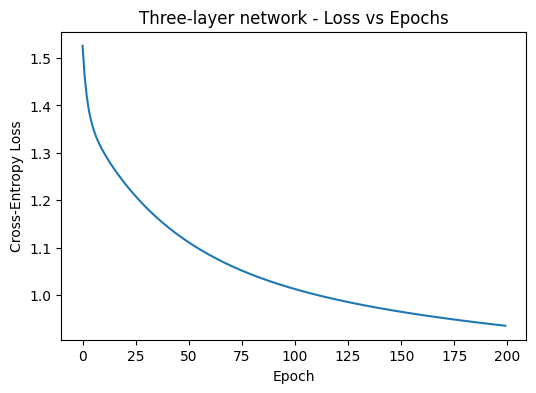

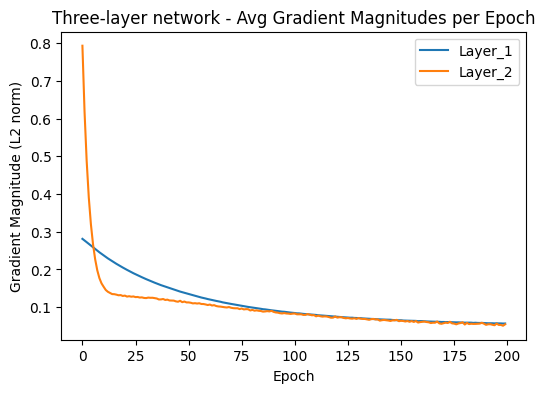


Training Four-layer network
Epoch 50/200 cost: 1.3586
Epoch 100/200 cost: 1.3220
Epoch 150/200 cost: 1.2614
Epoch 200/200 cost: 1.1787
Four-layer network accuracy: 0.5201


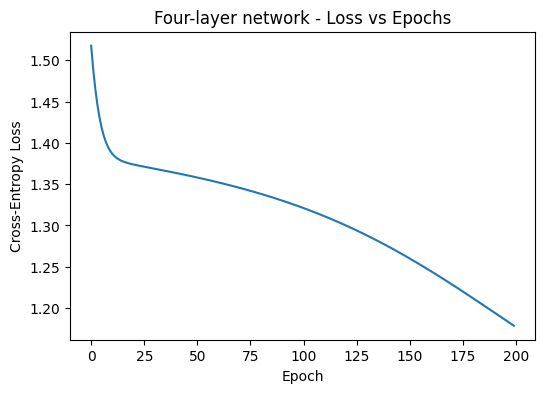

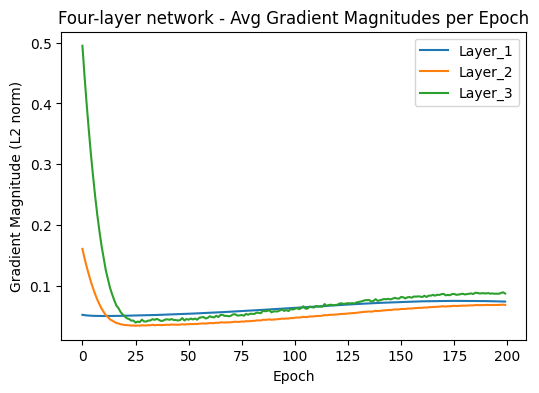


Training Five-layer network
Epoch 50/200 cost: 1.3840
Epoch 100/200 cost: 1.3822
Epoch 150/200 cost: 1.3802
Epoch 200/200 cost: 1.3778
Five-layer network accuracy: 0.4270


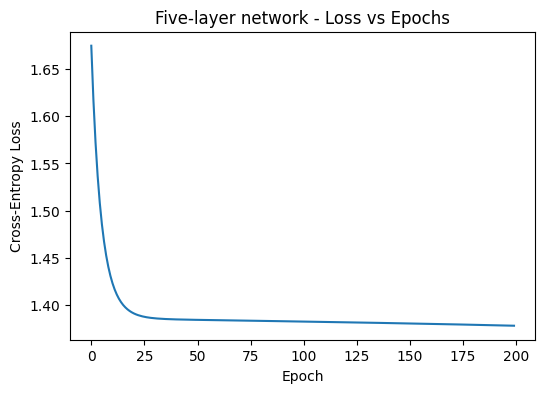

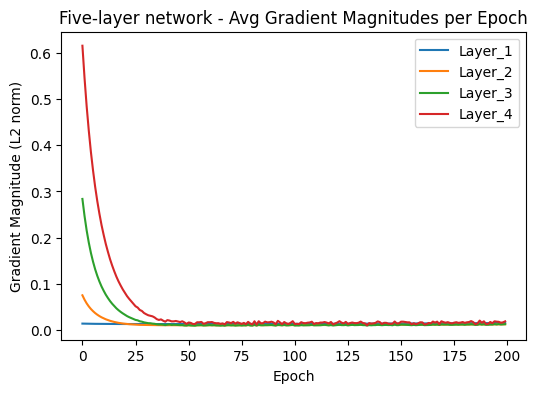

In [114]:
models = {}
for layers, label in zip([[30,], [30, 20], [30, 20, 10]], ["Three-layer", "Four-layer", "Five-layer"]):
    print(f"\nTraining {label} network")
    mlp = MultiLayerPerceptron(hidden_layers=layers, epochs=200, eta=0.01, minibatches=10)
    mlp.fit(X_train_full, y_train, print_progress=50)
    y_pred = mlp.predict(X_test_full)
    acc = accuracy_score(y_test, y_pred)
    models[label] = (mlp, acc)
    print(f"{label} network accuracy: {acc:.4f}")
    
    # Plot training loss
    plt.figure(figsize=(6,4))
    plt.plot(mlp.cost_)
    plt.title(f"{label} network - Loss vs Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.show()
    
    # Plot gradient magnitudes per layer
    plt.figure(figsize=(6,4))
    for key, mags in mlp.grad_mags.items():
        plt.plot(mags, label=key)
    plt.title(f"{label} network - Avg Gradient Magnitudes per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Gradient Magnitude (L2 norm)")
    plt.legend()
    plt.show()